In [9]:
%pip install --upgrade transformers --user

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Object Detection
%pip install timm
%pip install Pillow

from transformers import DetrImageProcessor, DetrForObjectDetection
image_processor = DetrImageProcessor.from_pretrained(
"facebook/detr-resnet-50")
model = DetrForObjectDetection.from_pretrained(
"facebook/detr-resnet-50")

# To know what objects the model was trained to detect
model.config.id2label

Note: you may need to restart the kernel to use updated packages.


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{0: 'N/A',
 1: 'person',
 10: 'traffic light',
 11: 'fire hydrant',
 12: 'street sign',
 13: 'stop sign',
 14: 'parking meter',
 15: 'bench',
 16: 'bird',
 17: 'cat',
 18: 'dog',
 19: 'horse',
 2: 'bicycle',
 20: 'sheep',
 21: 'cow',
 22: 'elephant',
 23: 'bear',
 24: 'zebra',
 25: 'giraffe',
 26: 'hat',
 27: 'backpack',
 28: 'umbrella',
 29: 'shoe',
 3: 'car',
 30: 'eye glasses',
 31: 'handbag',
 32: 'tie',
 33: 'suitcase',
 34: 'frisbee',
 35: 'skis',
 36: 'snowboard',
 37: 'sports ball',
 38: 'kite',
 39: 'baseball bat',
 4: 'motorcycle',
 40: 'baseball glove',
 41: 'skateboard',
 42: 'surfboard',
 43: 'tennis racket',
 44: 'bottle',
 45: 'plate',
 46: 'wine glass',
 47: 'cup',
 48: 'fork',
 49: 'knife',
 5: 'airplane',
 50: 'spoon',
 51: 'bowl',
 52: 'banana',
 53: 'apple',
 54: 'sandwich',
 55: 'orange',
 56: 'broccoli',
 57: 'carrot',
 58: 'hot dog',
 59: 'pizza',
 6: 'bus',
 60: 'donut',
 61: 'cake',
 62: 'chair',
 63: 'couch',
 64: 'potted plant',
 65: 'bed',
 66: 'mirror',
 67

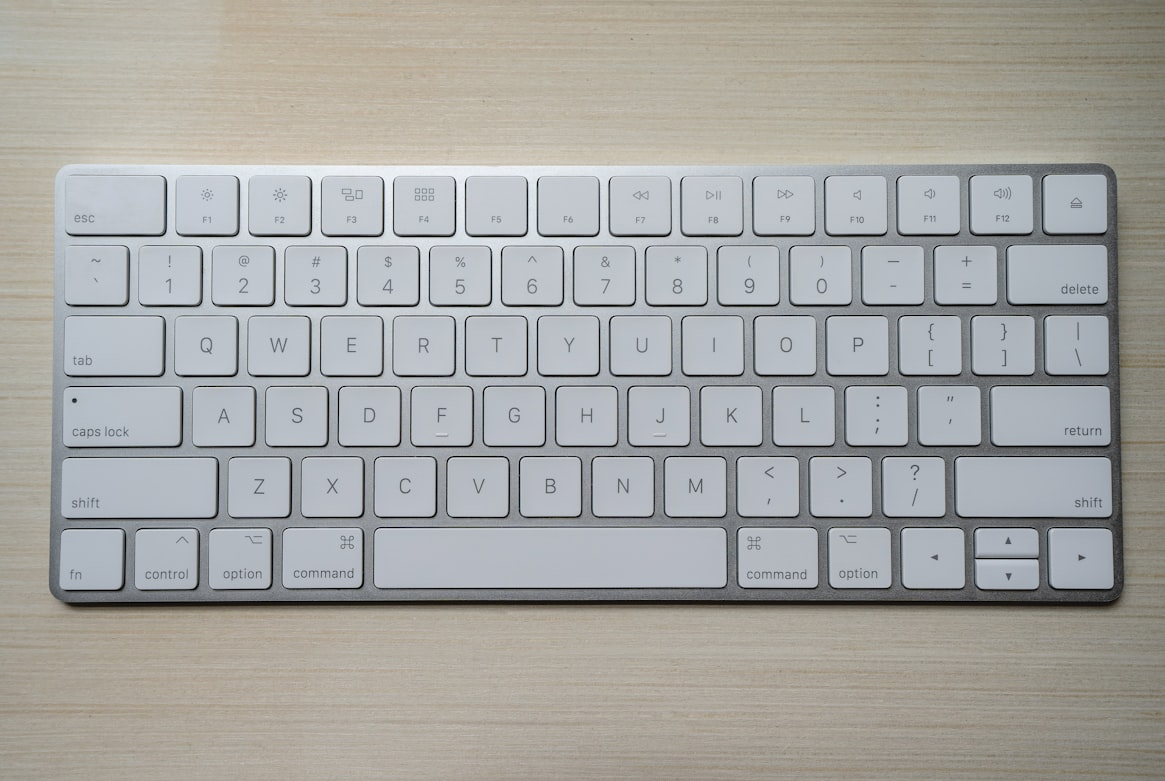

In [10]:
from PIL import Image, ImageDraw
import requests
import torch

def loadImage(url):
    if url.startswith('http'):
        image = Image.open(requests.get(url, stream=True).raw)
    else:
        image = Image.open(url)
    return image

image = loadImage('https://images.unsplash.com/photo-1587829741301-dc798b83add3?q=80&w=1165&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D')
display(image)


In [12]:
inputs = image_processor(images = image, return_tensors="pt")
# print(inputs)

outputs = model(**inputs)

{'pixel_mask': tensor([[[1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         ...,
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1]]]), 'pixel_values': tensor([[[[ 0.8618,  0.8618,  0.8447,  ..., -0.1143, -0.1143, -0.1143],
          [ 0.8618,  0.8618,  0.8447,  ..., -0.1486, -0.1486, -0.1486],
          [ 0.8789,  0.8789,  0.8789,  ..., -0.1657, -0.1657, -0.1657],
          ...,
          [ 0.5364,  0.5193,  0.5193,  ...,  0.0912,  0.0741,  0.0569],
          [ 0.5536,  0.5707,  0.6049,  ...,  0.0056, -0.0116, -0.0116],
          [ 0.5878,  0.6049,  0.6392,  ..., -0.0458, -0.0629, -0.1143]],

         [[ 0.9755,  0.9755,  0.9580,  ..., -0.0224, -0.0224, -0.0224],
          [ 0.9755,  0.9755,  0.9580,  ..., -0.0574, -0.0574, -0.0574],
          [ 0.9755,  0.9930,  0.9755,  ..., -0.0924, -0.0924, -0.0924],
          ...,
          [ 0.6078,  0.5903,  0.5903,  ...,  0.1702,  0.1527, 

In [25]:
target_sizes = torch.tensor([image.size[::-1]])

results = image_processor.post_process_object_detection(outputs, 
                                                        target_sizes = target_sizes, 
                                                        threshold = 0.9)[0]
results

print(results)
print(f"Image is a {model.config.id2label[results['labels'][0].item()]}")
'''
Summary of that post_process_object_detection, output of the model that was created earlier
- Target size of the image
- Threshold value for filtering out predictions (in this case, return only those with
confidence greater than 90%)
'''

{'scores': tensor([0.9969], grad_fn=<IndexBackward0>), 'labels': tensor([76]), 'boxes': tensor([[  46.8721,  151.9791, 1126.5413,  614.4081]],
       grad_fn=<IndexBackward0>)}
Image is a keyboard


'\nSummary of that post_process_object_detection, output of the model that was created earlier\n- Target size of the image\n- Threshold value for filtering out predictions (in this case, return only those with\nconfidence greater than 90%)\n'